<h1> Geometric Operations and Other Mathematical Tools with OpenCV</h1>


Estimated time needed: **40** minutes


<h2> Spatial Operations in Image Processing</h2>


Spatial operations use  pixels in a neighborhood to determine the present pixel value. Applications include filtering and sharpening. They are used in many steps in computer vision like segmentation and are a key building block in Artificial Intelligence algorithms.


- Linear Filtering
    - Filtering Noise
    - Gaussian Blur
    - Image Sharpening
- Edges
- Median
- Threshold


* * *


In [1]:
import urllib.request

urllib.request.urlretrieve("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/cameraman.jpeg", "cameraman.jpeg")
urllib.request.urlretrieve("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/lenna.png", "lenna.png")
urllib.request.urlretrieve("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/barbara.png", "barbara.png")

('barbara.png', <http.client.HTTPMessage at 0x25c18fbcdd0>)

Đoạn code này tải xuống các hình ảnh cần thiết cho bài lab.

In [2]:
# Used to view the images
import matplotlib.pyplot as plt
# Used to perform filtering on an image
import cv2
# Used to create kernels for filtering
import numpy as np

Đoạn code này nhập các thư viện cần thiết để xử lý hình ảnh và vẽ đồ thị.

In [3]:
def plot_image(image_1, image_2,title_1="Orignal",title_2="New Image"):
    plt.figure(figsize=(10,10))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(image_1, cv2.COLOR_BGR2RGB))
    plt.title(title_1)
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(image_2, cv2.COLOR_BGR2RGB))
    plt.title(title_2)
    plt.show()

Đoạn code này định nghĩa hàm để vẽ hai hình ảnh cạnh nhau để so sánh.

[[[125 137 226]
  [125 137 226]
  [133 137 223]
  ...
  [122 148 230]
  [110 130 221]
  [ 90  99 200]]

 [[125 137 226]
  [125 137 226]
  [133 137 223]
  ...
  [122 148 230]
  [110 130 221]
  [ 90  99 200]]

 [[125 137 226]
  [125 137 226]
  [133 137 223]
  ...
  [122 148 230]
  [110 130 221]
  [ 90  99 200]]

 ...

 [[ 60  18  84]
  [ 60  18  84]
  [ 58  27  92]
  ...
  [ 84  73 173]
  [ 76  68 172]
  [ 79  62 177]]

 [[ 57  22  82]
  [ 57  22  82]
  [ 62  32  96]
  ...
  [ 79  70 179]
  [ 81  71 181]
  [ 81  74 185]]

 [[ 57  22  82]
  [ 57  22  82]
  [ 62  32  96]
  ...
  [ 79  70 179]
  [ 81  71 181]
  [ 81  74 185]]]


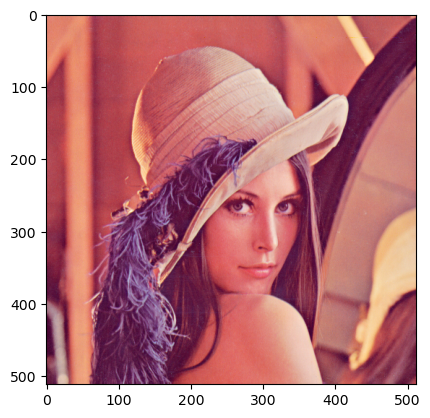

In [4]:
# Loads the image from the specified file
image = cv2.imread("lenna.png")
print(image)
# Converts the order of the color from BGR (Blue Green Red) to RGB (Red Green Blue) then renders the image from the array of data
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

Đoạn code này tải hình ảnh lenna.png và hiển thị nó.

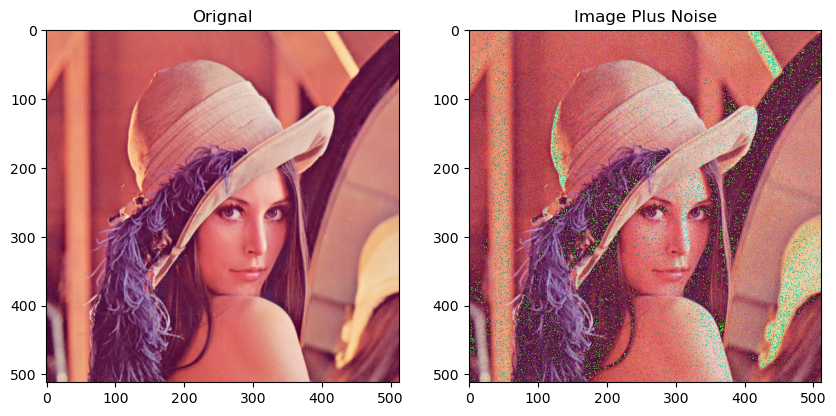

In [5]:
# Get the number of rows and columns in the image
rows, cols,_= image.shape
# Creates values using a normal distribution with a mean of 0 and standard deviation of 15, the values are converted to unit8 which means the values are between 0 and 255
noise = np.random.normal(0,15,(rows,cols,3)).astype(np.uint8)
# Add the noise to the image
noisy_image = image + noise
# Plots the original image and the image with noise using the function defined at the top
plot_image(image, noisy_image, title_1="Orignal",title_2="Image Plus Noise")

Đoạn code này thêm nhiễu ngẫu nhiên vào hình ảnh để mô phỏng hình ảnh có nhiễu.

In [6]:
# Create a kernel which is a 6 by 6 array where each value is 1/36
kernel = np.ones((6,6))/36

Đoạn code này nhập thư viện OpenCV để xử lý hình ảnh.

In [7]:
# Filters the images using the kernel
image_filtered = cv2.filter2D(src=noisy_image, ddepth=-1, kernel=kernel)

Đoạn code này tạo kernel lọc trung bình 6x6.

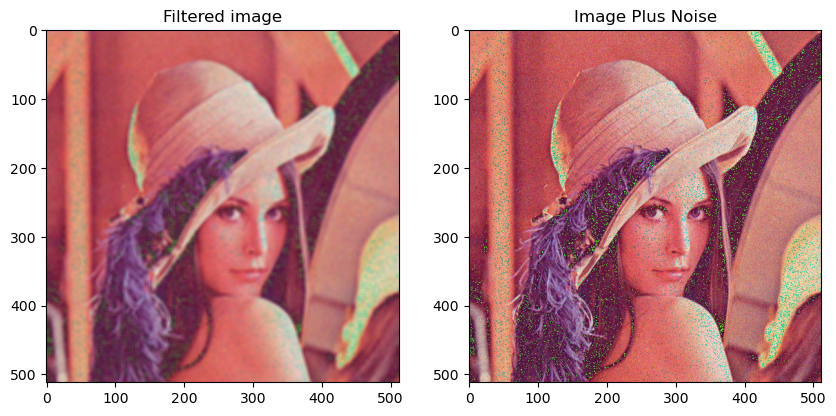

In [8]:
# Plots the Filtered and Image with Noise using the function defined at the top
plot_image(image_filtered, noisy_image,title_1="Filtered image",title_2="Image Plus Noise")

Đoạn code này áp dụng bộ lọc trung bình cho hình ảnh có nhiễu.

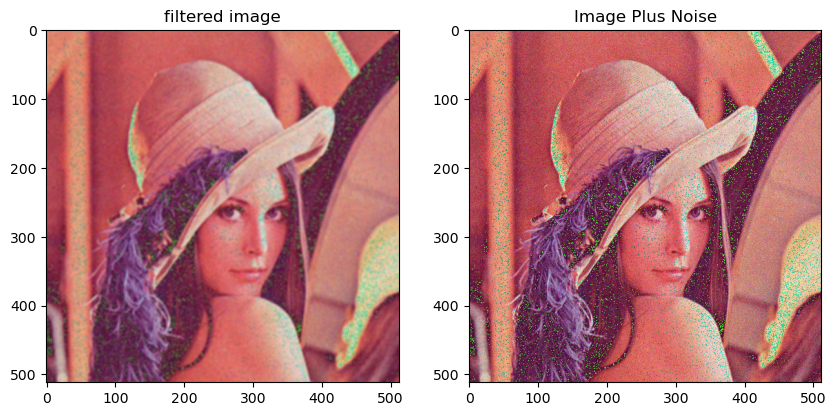

In [9]:
# Creates a kernel which is a 4 by 4 array where each value is 1/16
kernel = np.ones((4,4))/16
# Filters the images using the kernel
image_filtered=cv2.filter2D(src=noisy_image,ddepth=-1,kernel=kernel)
# Plots the Filtered and Image with Noise using the function defined at the top
plot_image(image_filtered , noisy_image,title_1="filtered image",title_2="Image Plus Noise")

Đoạn code này vẽ hình ảnh đã lọc và hình ảnh có nhiễu cạnh nhau.

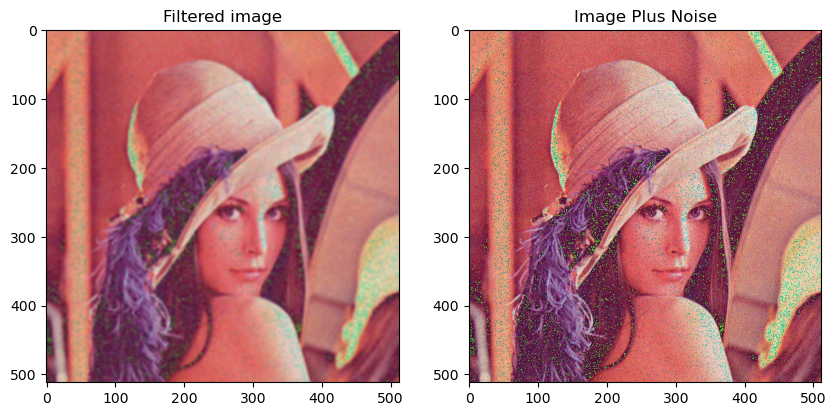

In [10]:
# Filters the images using GaussianBlur on the image with noise using a 4 by 4 kernel 
image_filtered = cv2.GaussianBlur(noisy_image,(5,5),sigmaX=4,sigmaY=4)
# Plots the Filtered Image then the Unfiltered Image with Noise
plot_image(image_filtered , noisy_image,title_1="Filtered image",title_2="Image Plus Noise")

Đoạn code này áp dụng làm mờ Gaussian cho hình ảnh có nhiễu.

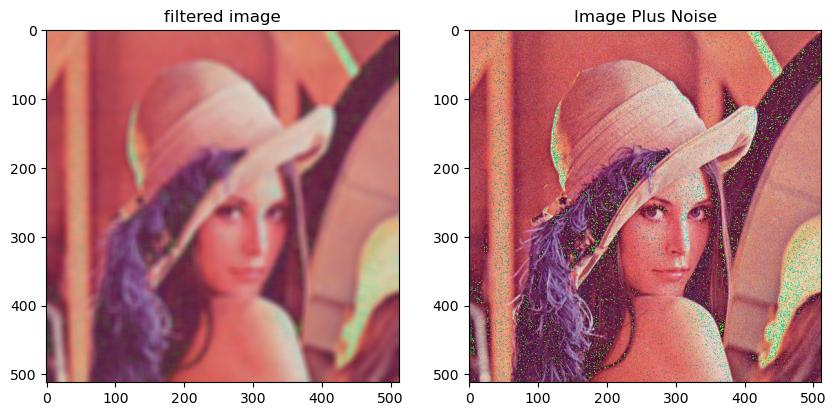

In [11]:
# Filters the images using GaussianBlur on the image with noise using a 11 by 11 kernel 
image_filtered = cv2.GaussianBlur(noisy_image,(11,11),sigmaX=10,sigmaY=10)
# Plots the Filtered Image then the Unfiltered Image with Noise
plot_image(image_filtered , noisy_image,title_1="filtered image",title_2="Image Plus Noise")

Đoạn code này áp dụng làm mờ Gaussian với sigma 2 cho hình ảnh có nhiễu.

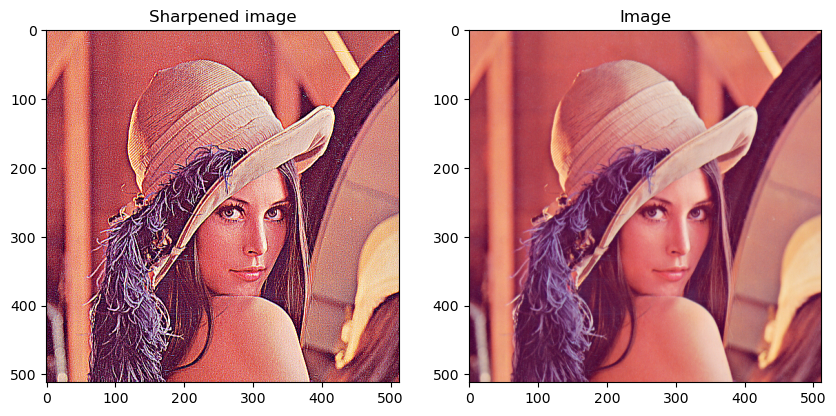

In [12]:
# Common Kernel for image sharpening
kernel = np.array([[-1,-1,-1], 
                   [-1, 9,-1],
                   [-1,-1,-1]])
# Applys the sharpening filter using kernel on the original image without noise
sharpened = cv2.filter2D(image, -1, kernel)
# Plots the sharpened image and the original image without noise
plot_image(sharpened , image, title_1="Sharpened image",title_2="Image")

Đoạn code này áp dụng bộ lọc làm sắc nét cho hình ảnh gốc.

[[181 201 202 ... 103 102  92]
 [171 198 201 ...  94  96  96]
 [175 195 193 ...  87  96  98]
 ...
 [100  97  97 ... 114 113 117]
 [ 94  97  99 ... 111 112 114]
 [ 96  95  98 ... 113 104 109]]


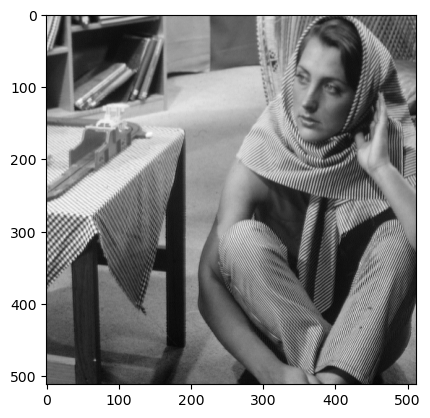

In [13]:
# Loads the image from the specified file
img_gray = cv2.imread('barbara.png', cv2.IMREAD_GRAYSCALE)
print(img_gray)
# Renders the image from the array of data, notice how it is 2 diemensional instead of 3 diemensional because it has no color
plt.imshow(img_gray ,cmap='gray')

Đoạn code này tải hình ảnh barbara.png và hiển thị nó ở thang độ xám.

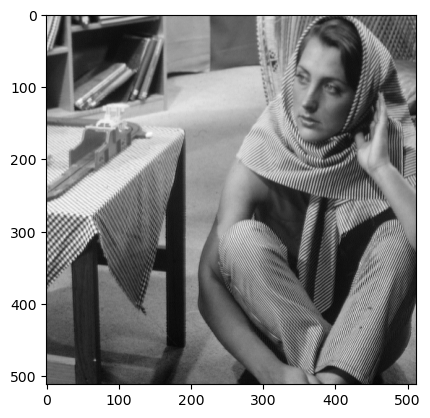

In [14]:
# Filters the images using GaussianBlur on the image with noise using a 3 by 3 kernel 
img_gray = cv2.GaussianBlur(img_gray,(3,3),sigmaX=0.1,sigmaY=0.1)
# Renders the filtered image
plt.imshow(img_gray ,cmap='gray')

Đoạn code này phát hiện cạnh bằng thuật toán Canny.

In [15]:
ddepth = cv2.CV_16S
# Applys the filter on the image in the X direction
grad_x = cv2.Sobel(src=img_gray, ddepth=ddepth, dx=1, dy=0, ksize=3)

Đoạn code này tải hình ảnh cameraman.jpeg và hiển thị nó.

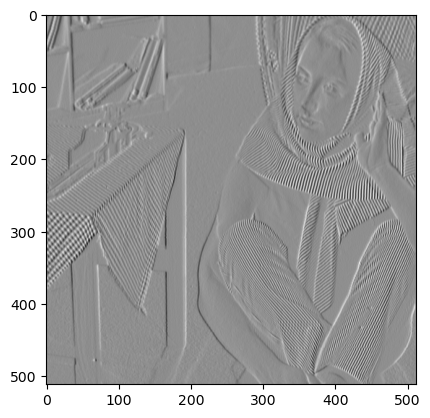

In [16]:
plt.imshow(grad_x,cmap='gray')

Đoạn code này áp dụng bộ lọc trung vị cho hình ảnh cameraman.

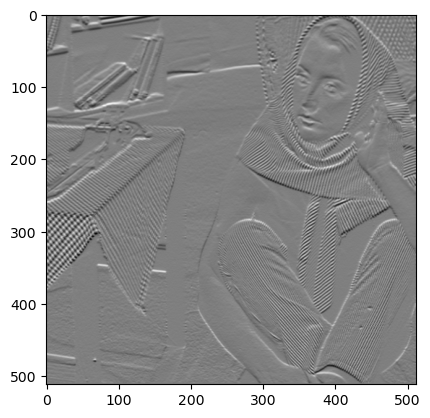

In [17]:
# Applys the filter on the image in the X direction
grad_y = cv2.Sobel(src=img_gray, ddepth=ddepth, dx=0, dy=1, ksize=3)
plt.imshow(grad_y,cmap='gray')

Đoạn code này áp dụng bộ lọc song phương cho hình ảnh cameraman.

In [18]:
# Converts the values back to a number between 0 and 255
abs_grad_x = cv2.convertScaleAbs(grad_x)
abs_grad_y = cv2.convertScaleAbs(grad_y)

Đoạn code này áp dụng phát hiện cạnh Canny cho hình ảnh barbara.

In [19]:
# Adds the derivative in the X and Y direction
grad = cv2.addWeighted(abs_grad_x, 0.5, abs_grad_y, 0.5, 0)

Đoạn code này tính gradient theo hướng X bằng toán tử Sobel.

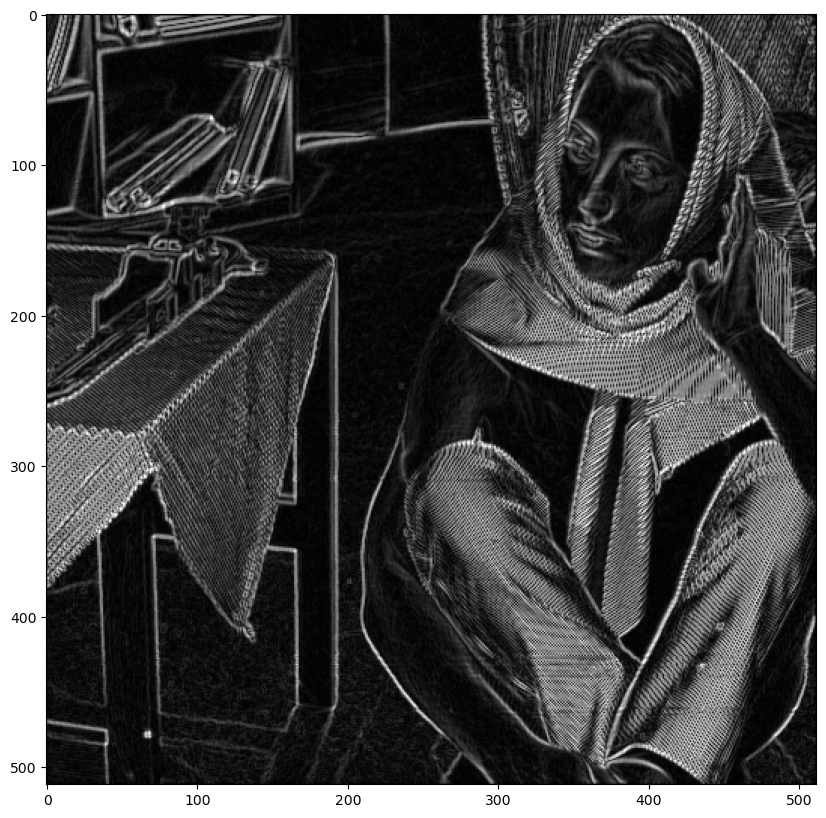

In [20]:
# Make the figure bigger and renders the image
plt.figure(figsize=(10,10))
plt.imshow(grad,cmap='gray')

Đoạn code này tính gradient theo hướng Y bằng toán tử Sobel.

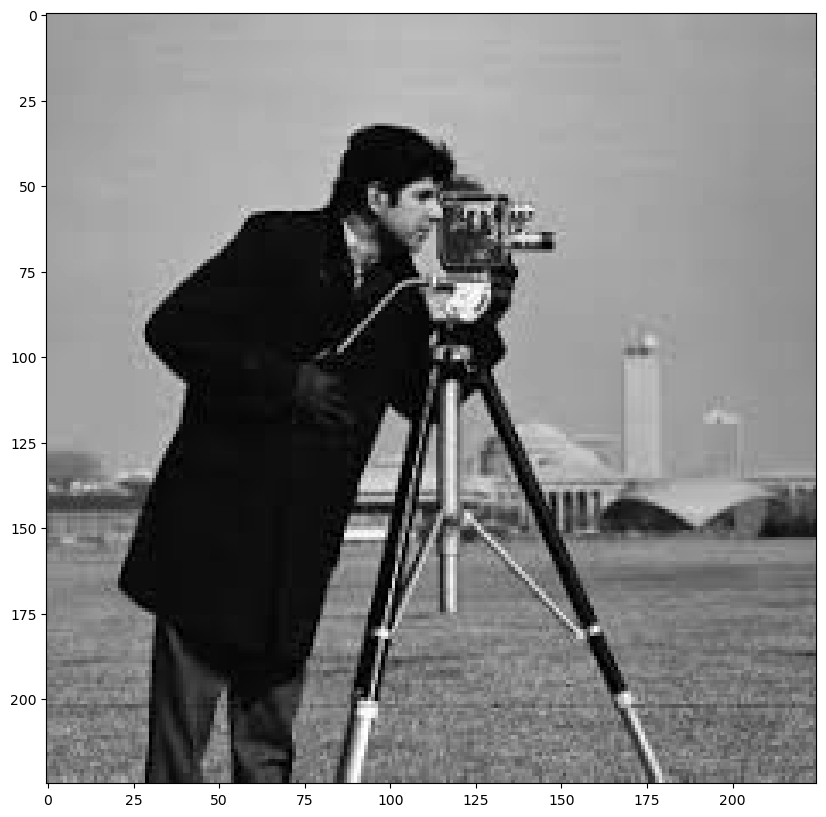

In [21]:
# Load the camera man image
image = cv2.imread("cameraman.jpeg",cv2.IMREAD_GRAYSCALE)
# Make the image larger when it renders
plt.figure(figsize=(10,10))
# Renders the image
plt.imshow(image,cmap="gray")

Đoạn code này tính độ lớn của gradient từ các gradient X và Y.

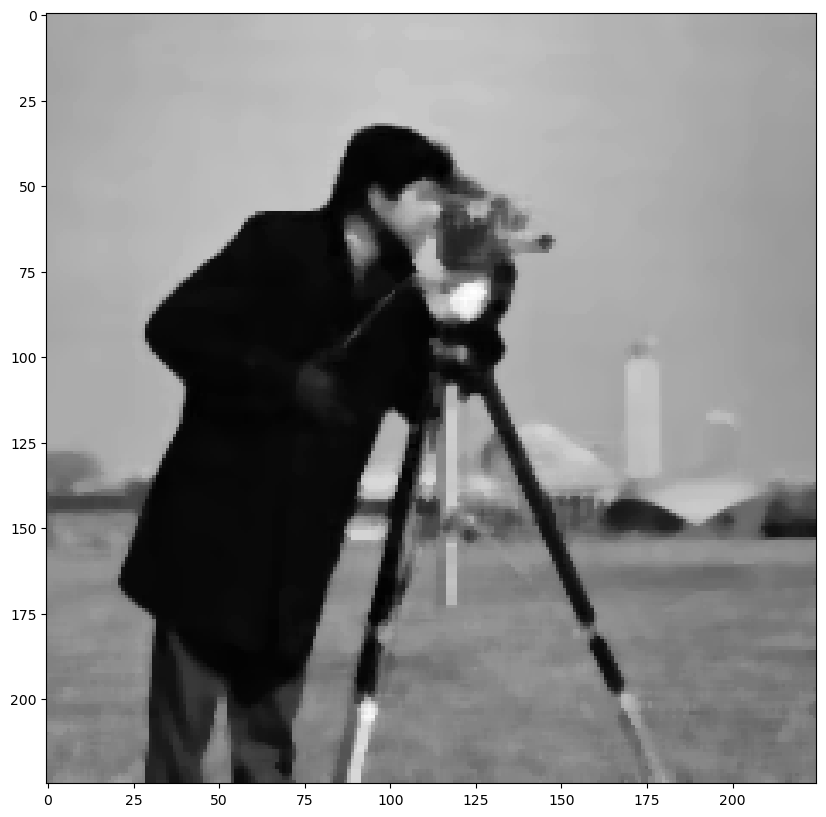

In [22]:
# Filter the image using Median Blur with a kernel of size 5
filtered_image = cv2.medianBlur(image, 5)
# Make the image larger when it renders
plt.figure(figsize=(10,10))
# Renders the image
plt.imshow(filtered_image,cmap="gray")

Đoạn code này áp dụng toán tử Laplacian để phát hiện cạnh.

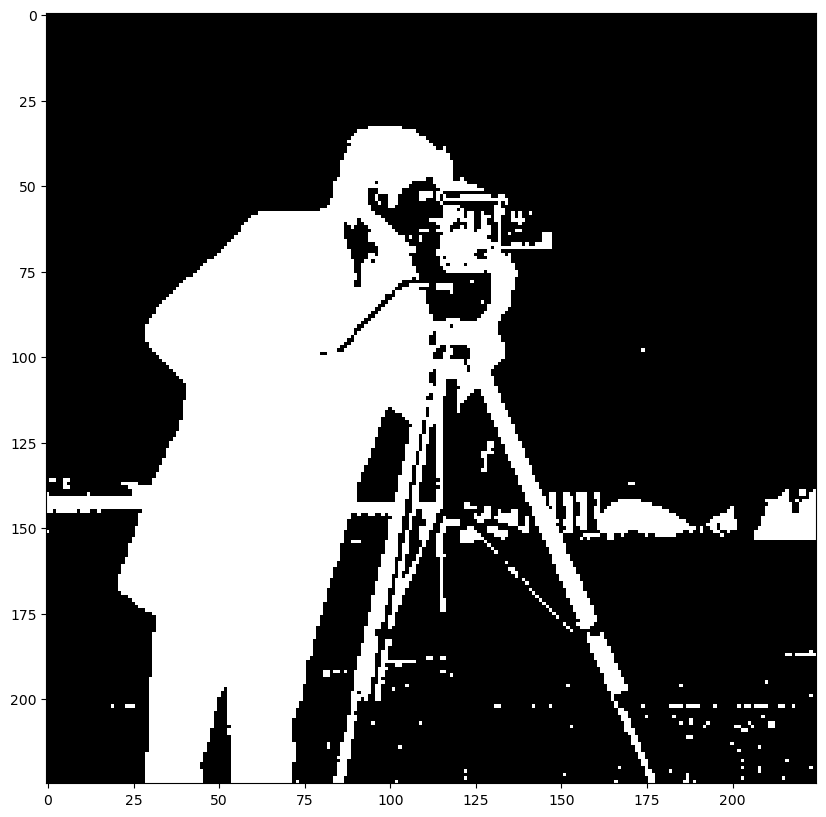

In [23]:
# Returns ret which is the threshold used and outs which is the image
ret, outs = cv2.threshold(src = image, thresh = 0, maxval = 255, type = cv2.THRESH_OTSU+cv2.THRESH_BINARY_INV)

# Make the image larger when it renders
plt.figure(figsize=(10,10))

# Render the image
plt.imshow(outs, cmap='gray')

Đoạn code này áp dụng kernel tùy chỉnh để lọc hình ảnh.

# References


[1]  Images were taken from: [https://homepages.cae.wisc.edu/~ece533/images/](https://homepages.cae.wisc.edu/~ece533/images/?utm_email=Email&utm_source=Nurture&utm_content=000026UJ&utm_term=10006555&utm_campaign=PLACEHOLDER&utm_id=SkillsNetwork-Courses-IBMDeveloperSkillsNetwork-CV0101EN-Coursera-25797139)

[2]  <a href='https://pillow.readthedocs.io/en/stable/index.html'>Pillow Docs</a>

[3]  <a href='https://opencv.org/'>Open CV</a>

[4] Gonzalez, Rafael C., and Richard E. Woods. "Digital image processing." (2017).

[5 ] Jian, Wushuai, Xueyan Sun, and Shuqian Luo. "Computer-aided diagnosis of breast microcalcifications based on dual-tree complex wavelet transform." Biomedical engineering online 11.1 (2012): 1-12.
